# 01 | Seven practical housing market questions

This notebook is **not a EDA**. Its purpose is to answer seven questions that may be useful to someone comparing housing markets across major Polish cities.

## Questions

1. How much does an apartment actually cost in my city?
2. Are apartments becoming easier or harder to afford relative to local wages?
3. Is the primary market price premium worth paying compared with the secondary market?
4. Is price growth in my city accelerating or slowing down?
5. Is a lot of new housing being built in my city?
6. Which cities look relatively more favorable from a buyer perspective?
7. Does an increase in the average price really mean that comparable homes became more expensive?

## Scope of the answers

This project **does not forecast prices**, estimate mortgage affordability, compare buying with renting, or observe the quality of a specific apartment.

The conclusions therefore answer **what the available data shows**, not whether someone should buy or wait.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## Data

The notebook uses only the cleaned tables produced by the validation pipeline. Raw data transformations are not repeated here.

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "processed").exists():
            return candidate
    raise FileNotFoundError("data/processed was not found.")

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
CLEAN_DIR = PROJECT_ROOT / "data" / "processed"

dim_city = pd.read_csv(CLEAN_DIR / "dim_city.csv", dtype={"teryt_code": "string"})
prices = pd.read_csv(CLEAN_DIR / "nbp_prices_clean.csv", dtype={"teryt_code": "string"})
hedonic = pd.read_csv(CLEAN_DIR / "nbp_hedonic_clean.csv")
income = pd.read_csv(CLEAN_DIR / "gus_income_clean.csv", dtype={"teryt_code": "string"})
market = pd.read_csv(CLEAN_DIR / "gus_market_clean.csv", dtype={"teryt_code": "string"})
supply = pd.read_csv(CLEAN_DIR / "gus_supply_clean.csv", dtype={"teryt_code": "string"})
population = pd.read_csv(CLEAN_DIR / "gus_population_clean.csv", dtype={"teryt_code": "string"})

expected_rows = {
    "dim_city": 17,
    "prices": 5440,
    "hedonic": 1280,
    "income": 408,
    "market": 1020,
    "supply": 8772,
    "population": 1054,
}

loaded = {
    "dim_city": dim_city,
    "prices": prices,
    "hedonic": hedonic,
    "income": income,
    "market": market,
    "supply": supply,
    "population": population,
}

check = pd.DataFrame({
    "rows": {name: len(df) for name, df in loaded.items()},
    "expected": expected_rows,
})
check["ok"] = check["rows"] == check["expected"]

display(check)
assert check["ok"].all()
assert dim_city["teryt_code"].str.fullmatch(r"\d{7}").all()

,rows,expected,ok
dim_city,17,17,True
prices,5440,5440,True
hedonic,1280,1280,True
income,408,408,True
market,1020,1020,True
supply,8772,8772,True
population,1054,1054,True


## Shared price preparation

Year over year growth is calculated only after sorting each `city × market × price type` series. A four period lag then refers to the same NBP period one year earlier.

In [3]:
prices_a = prices.sort_values(
    ["city_id", "market_type", "price_type", "nbp_year", "nbp_quarter"]
).copy()

price_group = prices_a.groupby(
    ["city_id", "market_type", "price_type"],
    sort=False
)

prices_a["price_prev_year"] = price_group["price_pln_m2"].shift(4)
prices_a["price_yoy_pct"] = (
    prices_a["price_pln_m2"] / prices_a["price_prev_year"] - 1
) * 100

latest_period_order = prices_a["nbp_period_order"].max()
latest_period = prices_a.loc[
    prices_a["nbp_period_order"].eq(latest_period_order),
    "nbp_period",
].iloc[0]

print("Latest NBP price period:", latest_period)

Latest NBP price period: 2026Q2


# 1. How much does an apartment actually cost in my city?

We use **transaction prices**, not offer prices.

For a more intuitive scale, an approximate cost of a 50 m² apartment is also shown as:

`average transaction price per m² × 50`

This is not the price of a specific apartment. It simply translates the price per square meter into a more practical amount.

In [4]:
latest_transaction_prices = (
    prices_a.loc[
        prices_a["nbp_period_order"].eq(latest_period_order)
        & prices_a["price_type"].eq("transaction"),
        ["city_id", "city_name", "market_type", "price_pln_m2"],
    ]
    .pivot(
        index=["city_id", "city_name"],
        columns="market_type",
        values="price_pln_m2",
    )
    .reset_index()
)

latest_transaction_prices["secondary_50m2_pln"] = (
    latest_transaction_prices["secondary"] * 50
)
latest_transaction_prices["primary_50m2_pln"] = (
    latest_transaction_prices["primary"] * 50
)

latest_transaction_prices = latest_transaction_prices.sort_values(
    "secondary",
    ascending=False,
)

display(
    latest_transaction_prices[
        [
            "city_name",
            "secondary",
            "secondary_50m2_pln",
            "primary",
            "primary_50m2_pln",
        ]
    ].rename(columns={
        "secondary": "secondary_pln_m2",
        "primary": "primary_pln_m2",
    })
)

market_type,city_name,secondary_pln_m2,secondary_50m2_pln,primary_pln_m2,primary_50m2_pln
13,Warszawa,"16,722.66","836,132.84","16,783.49","839,174.57"
6,Kraków,"14,791.95","739,597.53","15,922.88","796,143.85"
2,Gdańsk,"14,034.64","701,732.10","14,490.61","724,530.73"
14,Wrocław,"12,589.78","629,489.13","14,312.25","715,612.69"
3,Gdynia,"12,266.80","613,339.76","12,886.98","644,349.10"
11,Rzeszów,"10,973.99","548,699.69","10,329.02","516,451.06"
10,Poznań,"10,890.79","544,539.58","12,765.86","638,292.94"
7,Lublin,"10,219.03","510,951.50","10,889.14","544,457.00"
0,Białystok,"9,403.13","470,156.59","10,926.22","546,310.94"
12,Szczecin,"9,363.22","468,160.82","11,427.47","571,373.51"


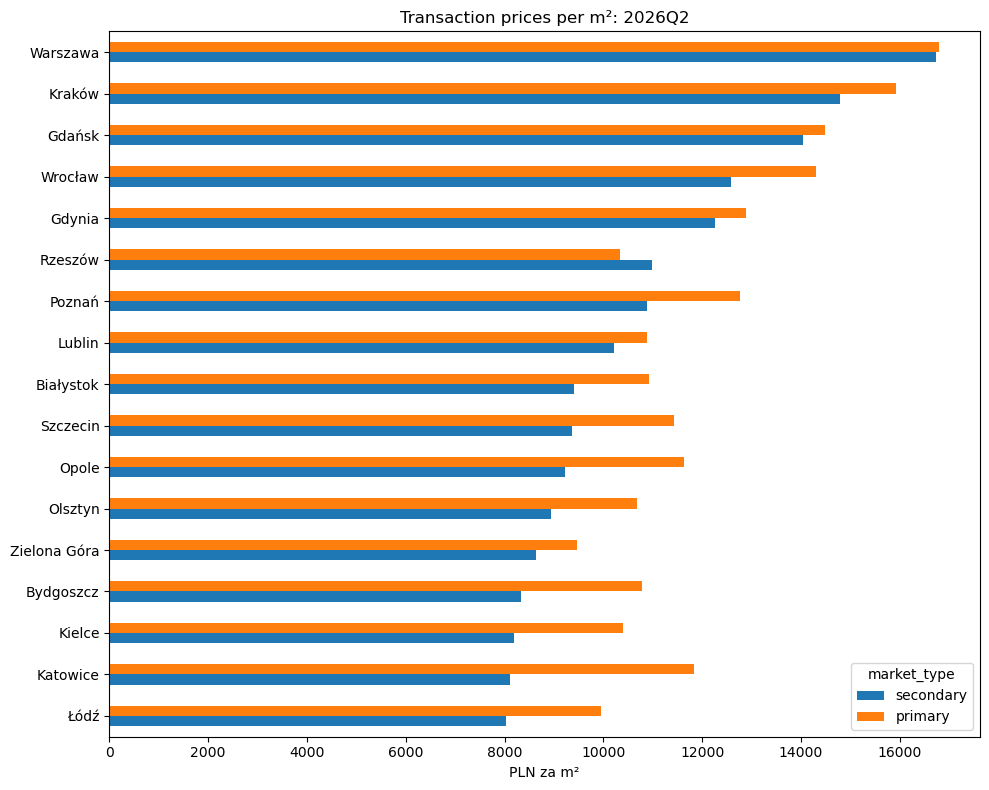

In [5]:
plot_data = (
    latest_transaction_prices
    .set_index("city_name")[["secondary", "primary"]]
    .sort_values("secondary")
)

ax = plot_data.plot(kind="barh", figsize=(10, 8))
ax.set_title(f"Transaction prices per m²: {latest_period}")
ax.set_xlabel("PLN za m²")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Answer

* Warszawa remains the most expensive market in the latest cross section.
* On the secondary market, Łódź and Katowice are currently the least expensive among the cities in the analysis.
* A price ranking alone does not show where housing is easiest to afford because local wages differ substantially. The next question therefore combines prices with wages.

# 2. Are apartments becoming easier or harder to afford relative to local wages?

We build a simple **affordability proxy**:

`average gross monthly wage / annual average transaction price per m²`

The result shows how many square meters correspond to one average gross monthly wage.

This is not mortgage affordability. It does not include loan payments, interest rates, taxes, or living costs.

In [6]:
annual_transaction_prices = (
    prices_a.loc[
        prices_a["price_type"].eq("transaction")
        & prices_a["nbp_year"].between(2007, 2025)
    ]
    .groupby(
        ["city_id", "city_name", "nbp_year", "market_type"],
        as_index=False,
    )
    .agg(
        annual_price_pln_m2=("price_pln_m2", "mean"),
        quarters_available=("price_pln_m2", "count"),
    )
    .rename(columns={"nbp_year": "year"})
)

annual_transaction_prices.loc[
    annual_transaction_prices["quarters_available"].lt(4),
    "annual_price_pln_m2",
] = np.nan

affordability = annual_transaction_prices.merge(
    income[
        [
            "city_id",
            "city_name",
            "year",
            "avg_gross_monthly_wage_pln",
        ]
    ],
    on=["city_id", "city_name", "year"],
    how="left",
    validate="many_to_one",
)

affordability["affordability_m2"] = (
    affordability["avg_gross_monthly_wage_pln"]
    / affordability["annual_price_pln_m2"]
)

affordability = affordability.sort_values(
    ["city_id", "market_type", "year"]
)

affordability["affordability_yoy_pct"] = (
    affordability
    .groupby(["city_id", "market_type"])["affordability_m2"]
    .pct_change(fill_method=None)
    * 100
)

affordability["annual_price_yoy_pct"] = (
    affordability
    .groupby(["city_id", "market_type"])["annual_price_pln_m2"]
    .pct_change(fill_method=None)
    * 100
)

affordability["wage_yoy_pct"] = (
    affordability
    .groupby(["city_id", "market_type"])["avg_gross_monthly_wage_pln"]
    .pct_change(fill_method=None)
    * 100
)

In [7]:
aff_2019 = (
    affordability.loc[
        affordability["year"].eq(2019),
        ["city_id", "market_type", "affordability_m2"],
    ]
    .rename(columns={"affordability_m2": "affordability_2019"})
)

aff_2025 = (
    affordability.loc[
        affordability["year"].eq(2025),
        [
            "city_id",
            "city_name",
            "market_type",
            "affordability_m2",
            "affordability_yoy_pct",
            "annual_price_yoy_pct",
            "wage_yoy_pct",
        ],
    ]
    .merge(
        aff_2019,
        on=["city_id", "market_type"],
        how="left",
        validate="one_to_one",
    )
)

aff_2025["affordability_change_since_2019_pct"] = (
    aff_2025["affordability_m2"]
    / aff_2025["affordability_2019"]
    - 1
) * 100

secondary_affordability_2025 = (
    aff_2025.loc[
        aff_2025["market_type"].eq("secondary"),
        [
            "city_name",
            "affordability_m2",
            "affordability_yoy_pct",
            "wage_yoy_pct",
            "annual_price_yoy_pct",
            "affordability_change_since_2019_pct",
        ],
    ]
    .sort_values("affordability_m2", ascending=False)
)

display(secondary_affordability_2025)

,city_name,affordability_m2,affordability_yoy_pct,wage_yoy_pct,annual_price_yoy_pct,affordability_change_since_2019_pct
9,Katowice,1.32,2.66,7.46,4.68,-0.49
3,Bydgoszcz,1.18,8.80,9.12,0.30,17.60
33,Łódź,1.16,4.58,8.73,3.97,6.44
31,Zielona Góra,1.11,-0.53,7.17,7.74,-5.01
11,Kielce,1.11,6.05,9.68,3.43,-4.54
17,Olsztyn,1.08,2.93,8.02,4.94,10.05
25,Szczecin,1.07,7.04,9.55,2.35,4.47
19,Opole,1.07,4.97,10.52,5.29,1.73
1,Białystok,0.96,2.58,9.76,7.01,4.75
21,Poznań,0.94,3.83,8.42,4.43,4.51


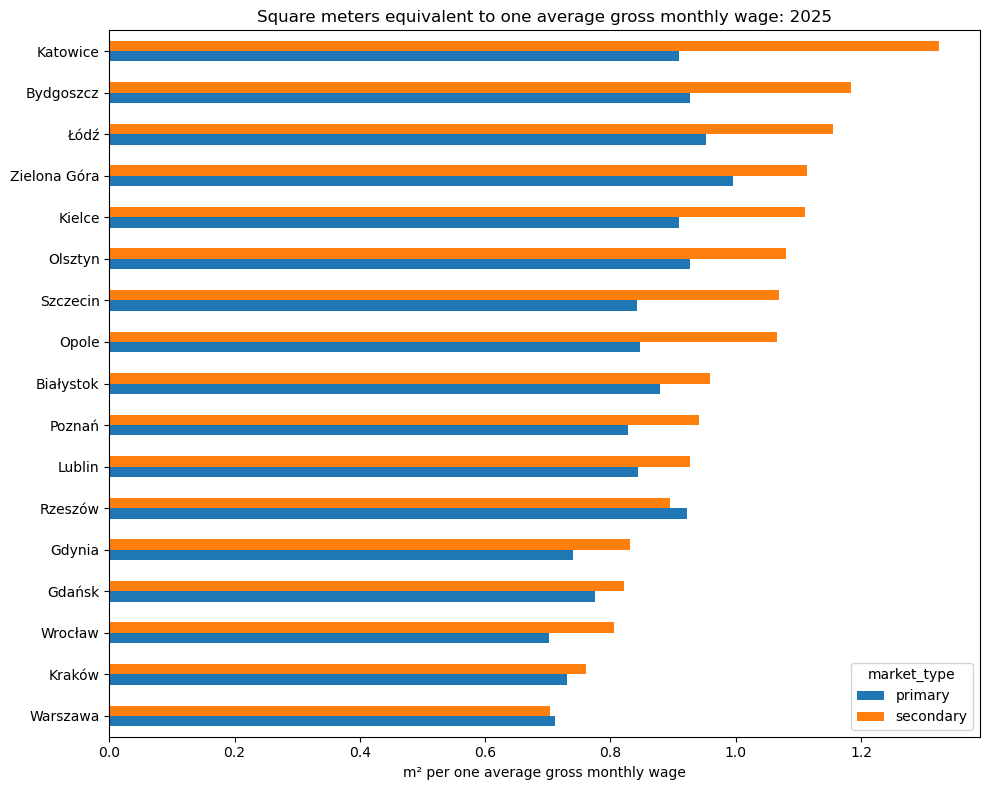

In [8]:
plot_data = (
    aff_2025
    .pivot(
        index="city_name",
        columns="market_type",
        values="affordability_m2",
    )
    .sort_values("secondary")
)

ax = plot_data.plot(kind="barh", figsize=(10, 8))
ax.set_title("Square meters equivalent to one average gross monthly wage: 2025")
ax.set_xlabel("m² per one average gross monthly wage")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### Answer

The practical question is **whether wages kept pace with prices**.

In 2025, secondary market affordability improved in 16 of 17 cities. Zielona Góra was the only exception.

This means that in most cities, wages grew faster in 2025 than the annual average transaction price per square meter.

The longer history is more mixed. For example, Warszawa, Wrocław, Zielona Góra, Kielce, and Rzeszów still had worse affordability in 2025 than in 2019. A short term improvement therefore does not imply that earlier deterioration has been fully reversed.

# 3. Is the primary market price premium worth paying compared with the secondary market?

The data does not capture quality, finish standard, exact location, or renovation costs.

It can still answer two practical questions:

* **How large is the current primary market premium?**
* **Is that premium typical relative to the history of the city?**

In [9]:
transaction_prices = prices_a.loc[
    prices_a["price_type"].eq("transaction")
].copy()

primary_secondary = (
    transaction_prices
    .pivot(
        index=["city_id", "city_name", "nbp_period", "nbp_period_order"],
        columns="market_type",
        values="price_pln_m2",
    )
    .reset_index()
)

primary_secondary["primary_premium_pct"] = (
    primary_secondary["primary"]
    / primary_secondary["secondary"]
    - 1
) * 100

premium_history = (
    primary_secondary
    .groupby(["city_id", "city_name"], as_index=False)
    .agg(
        historical_median_premium_pct=("primary_premium_pct", "median"),
        historical_min_premium_pct=("primary_premium_pct", "min"),
        historical_max_premium_pct=("primary_premium_pct", "max"),
    )
)

premium_now = (
    primary_secondary.loc[
        primary_secondary["nbp_period_order"].eq(latest_period_order),
        ["city_id", "city_name", "primary", "secondary", "primary_premium_pct"],
    ]
    .merge(
        premium_history,
        on=["city_id", "city_name"],
        how="left",
        validate="one_to_one",
    )
)

premium_now["vs_historical_median_pp"] = (
    premium_now["primary_premium_pct"]
    - premium_now["historical_median_premium_pct"]
)

premium_now = premium_now.sort_values(
    "primary_premium_pct",
    ascending=False,
)

display(premium_now)

,city_id,city_name,primary,secondary,primary_premium_pct,historical_median_premium_pct,historical_min_premium_pct,historical_max_premium_pct,vs_historical_median_pp
4,5,Katowice,"11,840.15","8,101.70",46.14,43.83,26.72,84.68,2.31
1,2,Bydgoszcz,"10,774.89","8,341.87",29.17,25.95,-1.28,41.99,3.22
5,6,Kielce,"10,401.90","8,192.65",26.97,21.73,-17.53,34.44,5.24
9,10,Opole,"11,624.60","9,215.28",26.14,15.51,-14.37,30.89,10.63
16,17,Łódź,"9,945.49","8,019.66",24.01,27.59,13.04,62.86,-3.57
12,13,Szczecin,"11,427.47","9,363.22",22.05,22.69,2.76,49.52,-0.64
8,9,Olsztyn,"10,680.51","8,940.51",19.46,12.03,-29.80,28.92,7.43
10,11,Poznań,"12,765.86","10,890.79",17.22,17.33,-6.03,50.98,-0.11
0,1,Białystok,"10,926.22","9,403.13",16.20,13.40,-1.52,24.39,2.80
14,15,Wrocław,"14,312.25","12,589.78",13.68,8.34,-26.41,25.01,5.35


### Answer

There is **no single stable primary market premium** across cities.

* Katowice: the primary market is currently about 46% more expensive than the secondary market.
* Warszawa: prices in the two segments are almost identical.
* Rzeszów: the primary market is currently cheaper than the secondary market.
* Gdynia and Zielona Góra currently have a premium clearly below their own historical median.
* Opole and Olsztyn currently have a premium clearly above their own historical median.

The question of primary versus secondary should therefore be evaluated **separately for each city**, not for Poland as a whole.

# 4. Is price growth in my city accelerating or slowing down?

We measure **price momentum** using:

* average year over year growth across the latest 4 NBP periods,
* average year over year growth across the previous 4 periods,
* the difference between those two averages.

This answers a descriptive question: **is the current pace of price change stronger or weaker than one year earlier?**

GUS market activity data ends earlier, so it is used only as older context rather than as an indicator of the current 2026 market.

In [10]:
transaction_series = prices_a.loc[
    prices_a["price_type"].eq("transaction")
].copy()

all_orders = sorted(transaction_series["nbp_period_order"].unique())
recent_4_orders = all_orders[-4:]
previous_4_orders = all_orders[-8:-4]

momentum_rows = []

for (city_id, city_name, market_type), group in transaction_series.groupby(
    ["city_id", "city_name", "market_type"]
):
    recent_avg = group.loc[
        group["nbp_period_order"].isin(recent_4_orders),
        "price_yoy_pct",
    ].mean()

    previous_avg = group.loc[
        group["nbp_period_order"].isin(previous_4_orders),
        "price_yoy_pct",
    ].mean()

    momentum_rows.append({
        "city_id": city_id,
        "city_name": city_name,
        "market_type": market_type,
        "recent_4q_avg_yoy_pct": recent_avg,
        "previous_4q_avg_yoy_pct": previous_avg,
        "momentum_change_pp": recent_avg - previous_avg,
    })

price_momentum = pd.DataFrame(momentum_rows)

def describe_price_state(row):
    recent = row["recent_4q_avg_yoy_pct"]
    change = row["momentum_change_pp"]

    if recent > 0 and change < 0:
        return "prices are still rising, but clearly more slowly"
    if recent > 0 and change >= 0:
        return "prices are rising and growth is accelerating"
    if recent <= 0 and change < 0:
        return "average prices are lower year over year after earlier strong growth"
    return "average prices are flat or falling, but the trend is improving"

price_momentum["interpretation"] = price_momentum.apply(
    describe_price_state,
    axis=1,
)

secondary_momentum = (
    price_momentum.loc[
        price_momentum["market_type"].eq("secondary")
    ]
    .sort_values("recent_4q_avg_yoy_pct", ascending=False)
)

display(secondary_momentum)

,city_id,city_name,market_type,recent_4q_avg_yoy_pct,previous_4q_avg_yoy_pct,momentum_change_pp,interpretation
31,16,Zielona Góra,secondary,7.75,12.75,-5.00,"prices are still rising, but clearly more slowly"
5,3,Gdańsk,secondary,4.47,10.41,-5.94,"prices are still rising, but clearly more slowly"
19,10,Opole,secondary,3.89,12.27,-8.38,"prices are still rising, but clearly more slowly"
17,9,Olsztyn,secondary,3.87,10.68,-6.81,"prices are still rising, but clearly more slowly"
23,12,Rzeszów,secondary,1.97,14.95,-12.98,"prices are still rising, but clearly more slowly"
15,8,Lublin,secondary,1.96,11.85,-9.89,"prices are still rising, but clearly more slowly"
3,2,Bydgoszcz,secondary,1.86,5.14,-3.27,"prices are still rising, but clearly more slowly"
21,11,Poznań,secondary,1.70,10.84,-9.14,"prices are still rising, but clearly more slowly"
7,4,Gdynia,secondary,1.49,12.21,-10.71,"prices are still rising, but clearly more slowly"
11,6,Kielce,secondary,1.49,12.22,-10.73,"prices are still rising, but clearly more slowly"


### Answer from the price data

The secondary market shows a very consistent pattern:

* In 14 of 17 cities, prices across the latest four periods were on average higher than one year earlier, **but the growth rate was lower than in the previous four period window**.
* Warszawa, Kraków, and Wrocław already had negative average year over year growth across the latest four periods.
* This is not a forecast of further declines. It shows that the earlier wave of price growth has clearly lost momentum.

## Older context: were people actually buying many homes?

For comparisons across all 17 cities, `sold_units` is used because the transaction count contains substantially more missing values in 2023 and 2024.

`transactions` and `sold_units` remain different variables. `sold_units` is used here because it provides a more complete cross section of market activity.

In [11]:
population_mid = population.loc[
    population["reference_date"].eq("mid_year"),
    ["city_id", "city_name", "year", "population"],
].copy()

market_annual = (
    market
    .groupby(["city_id", "city_name", "year"], as_index=False)
    .agg(
        sold_units=("sold_units", lambda s: s.sum(min_count=4)),
        transactions=("transactions", lambda s: s.sum(min_count=4)),
    )
    .merge(
        population_mid,
        on=["city_id", "city_name", "year"],
        how="left",
        validate="one_to_one",
    )
)

market_annual["sold_units_per_1000"] = (
    market_annual["sold_units"]
    / market_annual["population"]
    * 1000
)

market_annual["transactions_per_1000"] = (
    market_annual["transactions"]
    / market_annual["population"]
    * 1000
)

activity_2024 = (
    market_annual.loc[
        market_annual["year"].eq(2024),
        [
            "city_name",
            "sold_units",
            "sold_units_per_1000",
            "transactions",
            "transactions_per_1000",
        ],
    ]
    .sort_values("sold_units_per_1000", ascending=False)
)

display(activity_2024)

,city_name,sold_units,sold_units_per_1000,transactions,transactions_per_1000
44,Gdańsk,"10,037.00",20.57,"9,985.00",20.47
74,Katowice,"5,565.00",20.01,"5,710.00",20.53
224,Wrocław,"13,194.00",19.59,"13,958.00",20.72
104,Kraków,"15,120.00",18.72,"14,770.00",18.29
164,Poznań,"9,744.00",18.15,"9,583.00",17.85
179,Rzeszów,"3,574.00",18.08,NaN,NaN
119,Lublin,"5,644.00",17.16,NaN,NaN
134,Olsztyn,"2,646.00",15.87,"2,696.00",16.17
14,Białystok,"4,402.00",15.13,"4,395.00",15.11
254,Łódź,"9,633.00",14.85,"9,679.00",14.92


### How to read market activity

The 2024 data shows that a large market in absolute terms does not have to be the most active after adjusting for city population.

At the same time, 2024 activity is not used to claim that the market is currently accelerating or slowing in 2026 because the data sources have different reference periods.

# 5. Is a lot of new housing being built in my city?

We examine two different stages:

* `started`: dwellings where construction started,
* `completed`: dwellings completed.

Full year 2025 values are shown per 1,000 residents. H1 2026 is compared only with H1 2025 so that a half year is never compared with a full year.

In [12]:
supply_full = supply.loc[
    supply["is_full_year"].eq(True)
].copy()

supply_annual_long = (
    supply_full
    .groupby(
        ["city_id", "city_name", "year", "supply_type"],
        as_index=False,
    )
    .agg(
        dwellings=(
            "period_value",
            lambda s: s.sum(min_count=12),
        )
    )
)

supply_annual = (
    supply_annual_long
    .pivot(
        index=["city_id", "city_name", "year"],
        columns="supply_type",
        values="dwellings",
    )
    .reset_index()
    .merge(
        population_mid,
        on=["city_id", "city_name", "year"],
        how="left",
        validate="one_to_one",
    )
)

supply_annual["started_per_1000"] = (
    supply_annual["started"]
    / supply_annual["population"]
    * 1000
)

supply_annual["completed_per_1000"] = (
    supply_annual["completed"]
    / supply_annual["population"]
    * 1000
)

supply_2025 = (
    supply_annual.loc[
        supply_annual["year"].eq(2025),
        [
            "city_id",
            "city_name",
            "started",
            "started_per_1000",
            "completed",
            "completed_per_1000",
        ],
    ]
    .sort_values("completed_per_1000", ascending=False)
)

display(supply_2025)

,city_id,city_name,started,started_per_1000,completed,completed_per_1000
251,12,Rzeszów,"1,824.00",9.19,"3,097.00",15.60
62,3,Gdańsk,"5,337.00",10.91,"5,750.00",11.75
314,15,Wrocław,"5,009.00",7.45,"7,700.00",11.45
293,14,Warszawa,"14,399.00",7.72,"19,844.00",10.65
230,11,Poznań,"3,130.00",5.85,"5,608.00",10.48
146,7,Kraków,"7,962.00",9.82,"7,946.00",9.80
356,17,Łódź,"7,520.00",11.70,"5,792.00",9.01
167,8,Lublin,"2,155.00",6.58,"2,907.00",8.88
104,5,Katowice,"3,291.00",11.84,"2,334.00",8.40
335,16,Zielona Góra,842.00,6.07,"1,063.00",7.66


In [13]:
h1_supply = (
    supply.loc[
        supply["year"].isin([2025, 2026])
        & supply["month"].le(6)
    ]
    .groupby(
        ["city_id", "city_name", "year", "supply_type"],
        as_index=False,
    )
    .agg(
        h1_dwellings=(
            "period_value",
            lambda s: s.sum(min_count=6),
        )
    )
)

h1_comparison = (
    h1_supply
    .pivot(
        index=["city_id", "city_name", "supply_type"],
        columns="year",
        values="h1_dwellings",
    )
    .reset_index()
    .rename(columns={2025: "h1_2025", 2026: "h1_2026"})
)

h1_comparison["h1_2026_vs_2025_pct"] = (
    h1_comparison["h1_2026"]
    / h1_comparison["h1_2025"]
    - 1
) * 100

display(
    h1_comparison.sort_values(
        ["supply_type", "h1_2026_vs_2025_pct"],
        ascending=[True, False],
    )
)

year,city_id,city_name,supply_type,h1_2025,h1_2026,h1_2026_vs_2025_pct
16,9,Olsztyn,completed,195.00,778.00,298.97
2,2,Bydgoszcz,completed,345.00,985.00,185.51
18,10,Opole,completed,165.00,323.00,95.76
12,7,Kraków,completed,"2,731.00","4,501.00",64.81
14,8,Lublin,completed,934.00,"1,433.00",53.43
20,11,Poznań,completed,"1,791.00","2,319.00",29.48
32,17,Łódź,completed,"2,263.00","2,602.00",14.98
8,5,Katowice,completed,"1,269.00","1,420.00",11.90
28,15,Wrocław,completed,"3,481.00","3,182.00",-8.59
22,12,Rzeszów,completed,"1,714.00","1,526.00",-10.97


### Answer

* Rzeszów, Gdańsk, and Wrocław were among the cities with the highest number of completed dwellings per capita in 2025.
* Katowice and Łódź ranked very high in dwellings started per capita.
* H1 2026 shows large differences between cities, but percentage changes should be read together with the base level. A several hundred percent increase can partly reflect a very low value one year earlier.
* `started` is not a price forecast. It only describes construction activity that may matter for future housing supply.

# 6. Which cities look relatively more favorable from a buyer perspective?

We do not create an arbitrary score such as 73 out of 100 because that would require subjective weights.

Instead, cities are compared through three practical dimensions:

1. **affordability**: more square meters per local wage is more favorable,
2. **new supply**: more completed dwellings per capita means a larger flow of new housing,
3. **price pressure**: lower recent price growth means less upward price pressure.

The current price level is also shown for context.

Finally, a **Pareto set** is identified using these three deliberately selected criteria. A city belongs to the set if no other city is clearly better across all three dimensions at the same time.

This is not an investment ranking and does not identify where housing will necessarily be the best purchase.

In [14]:
secondary_price_now = (
    prices_a.loc[
        prices_a["nbp_period_order"].eq(latest_period_order)
        & prices_a["market_type"].eq("secondary")
        & prices_a["price_type"].eq("transaction"),
        ["city_id", "city_name", "price_pln_m2"],
    ]
    .rename(columns={"price_pln_m2": "secondary_transaction_price_pln_m2"})
)

secondary_aff_2025 = (
    affordability.loc[
        affordability["year"].eq(2025)
        & affordability["market_type"].eq("secondary"),
        ["city_id", "city_name", "affordability_m2"],
    ]
    .rename(columns={"affordability_m2": "secondary_affordability_m2"})
)

secondary_recent_momentum = (
    price_momentum.loc[
        price_momentum["market_type"].eq("secondary"),
        [
            "city_id",
            "city_name",
            "recent_4q_avg_yoy_pct",
            "momentum_change_pp",
        ],
    ]
)

buyer_profile = (
    secondary_price_now
    .merge(
        secondary_aff_2025,
        on=["city_id", "city_name"],
        validate="one_to_one",
    )
    .merge(
        supply_2025[
            ["city_id", "city_name", "completed_per_1000"]
        ],
        on=["city_id", "city_name"],
        validate="one_to_one",
    )
    .merge(
        secondary_recent_momentum,
        on=["city_id", "city_name"],
        validate="one_to_one",
    )
)

buyer_profile = buyer_profile.sort_values(
    "secondary_affordability_m2",
    ascending=False,
)

display(buyer_profile)

,city_id,city_name,secondary_transaction_price_pln_m2,secondary_affordability_m2,completed_per_1000,recent_4q_avg_yoy_pct,momentum_change_pp
4,5,Katowice,"8,101.70",1.32,8.40,1.41,-8.16
1,2,Bydgoszcz,"8,341.87",1.18,3.65,1.86,-3.27
16,17,Łódź,"8,019.66",1.16,9.01,0.72,-9.35
15,16,Zielona Góra,"8,633.38",1.11,7.66,7.75,-5.00
5,6,Kielce,"8,192.65",1.11,5.82,1.49,-10.73
8,9,Olsztyn,"8,940.51",1.08,3.62,3.87,-6.81
12,13,Szczecin,"9,363.22",1.07,6.18,1.43,-7.22
9,10,Opole,"9,215.28",1.07,2.92,3.89,-8.38
0,1,Białystok,"9,403.13",0.96,5.84,0.66,-13.32
10,11,Poznań,"10,890.79",0.94,10.48,1.70,-9.14


In [15]:
def dominates(candidate, other):
    better_or_equal = (
        candidate["secondary_affordability_m2"]
        >= other["secondary_affordability_m2"]
        and candidate["completed_per_1000"]
        >= other["completed_per_1000"]
        and candidate["recent_4q_avg_yoy_pct"]
        <= other["recent_4q_avg_yoy_pct"]
    )

    strictly_better_somewhere = (
        candidate["secondary_affordability_m2"]
        > other["secondary_affordability_m2"]
        or candidate["completed_per_1000"]
        > other["completed_per_1000"]
        or candidate["recent_4q_avg_yoy_pct"]
        < other["recent_4q_avg_yoy_pct"]
    )

    return better_or_equal and strictly_better_somewhere

pareto_mask = []

for i, row in buyer_profile.iterrows():
    dominated = False

    for j, candidate in buyer_profile.iterrows():
        if i == j:
            continue

        if dominates(candidate, row):
            dominated = True
            break

    pareto_mask.append(not dominated)

buyer_profile["pareto_favorable"] = pareto_mask

pareto_cities = (
    buyer_profile.loc[
        buyer_profile["pareto_favorable"]
    ]
    .sort_values(
        "secondary_affordability_m2",
        ascending=False,
    )
)

display(pareto_cities)

,city_id,city_name,secondary_transaction_price_pln_m2,secondary_affordability_m2,completed_per_1000,recent_4q_avg_yoy_pct,momentum_change_pp,pareto_favorable
4,5,Katowice,"8,101.70",1.32,8.40,1.41,-8.16,True
16,17,Łódź,"8,019.66",1.16,9.01,0.72,-9.35,True
0,1,Białystok,"9,403.13",0.96,5.84,0.66,-13.32,True
10,11,Poznań,"10,890.79",0.94,10.48,1.70,-9.14,True
11,12,Rzeszów,"10,973.99",0.89,15.60,1.97,-12.98,True
14,15,Wrocław,"12,589.78",0.81,11.45,-1.36,-11.09,True


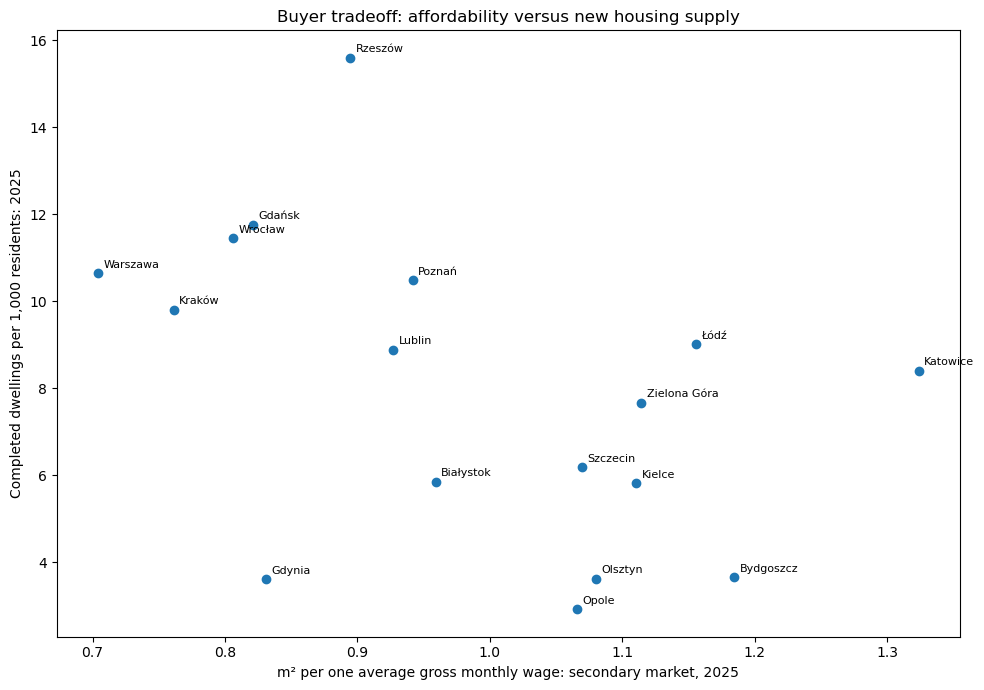

In [16]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    buyer_profile["secondary_affordability_m2"],
    buyer_profile["completed_per_1000"],
)

for _, row in buyer_profile.iterrows():
    ax.annotate(
        row["city_name"],
        (
            row["secondary_affordability_m2"],
            row["completed_per_1000"],
        ),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_title("Buyer tradeoff: affordability versus new housing supply")
ax.set_xlabel("m² per one average gross monthly wage: secondary market, 2025")
ax.set_ylabel("Completed dwellings per 1,000 residents: 2025")
plt.tight_layout()
plt.show()

### Answer

Without arbitrary weights, **there is no single objectively best city**.

Using these three criteria, the Pareto set contains:

* Katowice,
* Łódź,
* Białystok,
* Poznań,
* Rzeszów,
* Wrocław.

This only means that no other city is simultaneously better than each of them on affordability, completed supply per capita, and lower recent price growth.

The profiles are very different. For example, Katowice has strong affordability but a very high primary market premium. Wrocław has weaker affordability, but high new supply and negative recent secondary market price growth.

This is why a **city profile is more informative than one composite score**.

# 7. Does an increase in the average price really mean that comparable homes became more expensive?

The average transaction price can change because a different mix of homes was sold in a given period.

For the secondary market, we therefore compare:

* year over year growth in the average transaction price,
* year over year growth in the NBP hedonic index.

The hedonic index attempts to control for changes in the quality and composition of homes sold.

Gdańsk and Gdynia do not have separate city level hedonic series in this table, so the `Trójmiasto` aggregate is not assigned to either city.

In [17]:
secondary_transactions = (
    prices_a.loc[
        prices_a["market_type"].eq("secondary")
        & prices_a["price_type"].eq("transaction")
    ]
    .copy()
)

hedonic_city = hedonic.loc[
    hedonic["geography_type"].eq("city")
].copy()

hedonic_city["hedonic_yoy_pct"] = (
    hedonic_city["hedonic_yoy_index"] - 100
)

price_vs_hedonic = secondary_transactions.merge(
    hedonic_city[
        [
            "geography",
            "nbp_period",
            "hedonic_yoy_pct",
        ]
    ],
    left_on=["city_name", "nbp_period"],
    right_on=["geography", "nbp_period"],
    how="inner",
    validate="one_to_one",
)

price_vs_hedonic["headline_minus_hedonic_pp"] = (
    price_vs_hedonic["price_yoy_pct"]
    - price_vs_hedonic["hedonic_yoy_pct"]
)

comparable = (
    price_vs_hedonic["price_yoy_pct"].notna()
    & price_vs_hedonic["hedonic_yoy_pct"].notna()
)

nonzero = (
    price_vs_hedonic["price_yoy_pct"].ne(0)
    & price_vs_hedonic["hedonic_yoy_pct"].ne(0)
)

price_vs_hedonic["comparison_available"] = comparable
price_vs_hedonic["opposite_direction"] = (
    comparable
    & nonzero
    & (
        np.sign(price_vs_hedonic["price_yoy_pct"])
        != np.sign(price_vs_hedonic["hedonic_yoy_pct"])
    )
)

latest_price_vs_hedonic = (
    price_vs_hedonic.loc[
        price_vs_hedonic["nbp_period_order"].eq(latest_period_order),
        [
            "city_name",
            "price_yoy_pct",
            "hedonic_yoy_pct",
            "headline_minus_hedonic_pp",
            "comparison_available",
            "opposite_direction",
        ],
    ]
    .sort_values(
        "headline_minus_hedonic_pp",
        ascending=False,
    )
)

display(latest_price_vs_hedonic)

,city_name,price_yoy_pct,hedonic_yoy_pct,headline_minus_hedonic_pp,comparison_available,opposite_direction
1119,Zielona Góra,6.91,3.71,3.20,True,False
159,Bydgoszcz,6.89,4.19,2.70,True,False
239,Katowice,-0.64,-3.04,2.39,True,False
879,Szczecin,1.72,-0.21,1.93,True,True
559,Olsztyn,5.28,4.55,0.73,True,False
799,Rzeszów,2.36,1.65,0.72,True,False
1039,Wrocław,-0.28,-0.99,0.71,True,False
639,Opole,5.36,4.68,0.68,True,False
399,Kraków,-1.11,-1.45,0.34,True,False
959,Warszawa,1.31,1.20,0.11,True,False


In [18]:
opposite_now = latest_price_vs_hedonic.loc[
    latest_price_vs_hedonic["opposite_direction"]
]

print("Cities where the latest average price and hedonic index move in opposite directions:")
display(opposite_now)

Cities where the latest average price and hedonic index move in opposite directions:


,city_name,price_yoy_pct,hedonic_yoy_pct,headline_minus_hedonic_pp,comparison_available,opposite_direction
879,Szczecin,1.72,-0.21,1.93,True,True
79,Białystok,-0.18,1.17,-1.35,True,True
1199,Łódź,-1.65,0.80,-2.45,True,True


### Answer

Not always.

In the latest period, three cities show opposite directions for the average transaction price and the hedonic index:

* **Łódź**: the average secondary price is down year over year while the hedonic index is slightly up.
* **Białystok**: the average price is slightly down while the hedonic index is up.
* **Szczecin**: the average price is up while the hedonic index is slightly down.

This is a practical warning that a headline such as average price increased or decreased can sometimes be misleading.

The comparison shows that a composition effect may be material.

# Final answers to the seven questions

## What the project can say with reasonable confidence

**1. How much does an apartment cost?**  
Yes. The notebook shows the latest average **transaction prices** per square meter for the primary and secondary markets, plus an approximate 50 m² scale.

**2. Are local wages keeping pace with prices?**  
Yes. The affordability proxy compares wages with the price per square meter and helps separate wage growth from price growth.

**3. Primary or secondary market?**  
From a price perspective, yes. The notebook shows the current primary market premium and compares it with the history of each city. Yet it does not evaluate property quality.

**4. Is price growth accelerating or slowing?**  
From the price data, yes. Secondary market growth has clearly weakened. This is not converted into a forecast of future prices.

**5. Is a lot of housing being built?**  
The notebook shows how much new housing is being completed across cities and how supply differs relative to population. Full year 2025 is compared per capita, while H1 2026 is compared only with H1 2025. However the data does not determine whether the level of construction is sufficient to reduce housing prices.

**6. Which cities look relatively more favorable?**  
The project can show tradeoffs. It does not create an artificial ranking based on subjective weights.

**7. Does the headline average price tell the full story?**  
Not always. Hedonic data shows cases where changes in the sales mix may affect the headline average price.

## Main principle

The notebook provides **evidence for decision making**. But it does not pretend that descriptive data can produce a certain buy now, wait, or two to three year price forecast.